# Exercise 9: Advanced Models

```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activities work
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_09/exercise_09_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_09/exercise_09_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps each
embedded activity for a link back to this page.
```

## What this notebook covers

This is Exercise 9 of *Machine Learning for Neuroscience*. A complete
prediction pipeline has already appeared several times in this course, so
this notebook focuses on what is new: four additional models and the ideas
behind them.

In this notebook you will:

1. compare principal component regression (PCR) with partial least squares (PLS);
2. connect SVM margins and support vectors to classification and regression;
3. explore how kernels create nonlinear models;
4. compare advanced models on the same ABIDE-II age-prediction task.

## 1. Why Consider More Advanced Models?

Neuroimaging predictors are numerous and correlated, so the information
that actually predicts an outcome may live in a much lower-dimensional
structure than the raw feature count suggests. That structure is not always
linear, and different models preserve and use information from the same
predictors differently -- one model's useful signal can be another model's
discarded noise.

```{admonition} Think first
:class: think-first
If two models receive the same participants and features, why can they
produce different predictions even when both are evaluated correctly?
```

## 2. Principal Component Regression

**Principal component regression (PCR)** means ordinary linear regression
using principal-component scores as predictors, in place of the original
features:

```python
Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=...)),
    ("model", LinearRegression()),
])
```

Exercise 8 already used PCA before a model; PCR is the same idea before
linear regression specifically, so it inherits PCA's own properties:

- PCA chooses directions that explain variation in `X`, without ever seeing
  the target.
- The number of retained components is a model parameter, chosen the same
  way any other model parameter is chosen.
- `StandardScaler` and `PCA` must both be fitted inside each validation
  fold, never once on the full dataset beforehand.
- PCR can reduce noise and collinearity in highly correlated predictors, but
  it can also discard a low-variance direction that happens to predict the
  target well -- PCA has no way to know that in advance.

## 3. Partial Least Squares

**Partial least squares (PLS) regression** also builds a small number of
components from many correlated predictors, but constructs them
differently: PCR's components summarize variation in the predictors alone,
while PLS's components are constructed using the relationship between the
predictors and the target. As a result, PLS can prioritize a direction that
explains relatively little variance in `X` but relates strongly to the
target -- exactly the direction PCR is at risk of discarding.

Because PLS's components are built using the target, fitting PLS is
supervised: the complete PLS fit -- not just the final linear step -- must
happen inside each training fold, never before a train/validation split.

```python
Pipeline([
    ("scale", StandardScaler()),
    # scale=False: the outer StandardScaler already standardized the
    # predictors, so PLSRegression's own internal scaling is turned off
    # here to avoid silently scaling twice.
    ("model", PLSRegression(n_components=..., scale=False)),
])
```

The number of PLS components is chosen using training/development data
only, the same way as any other model parameter.

## 4. Interactive Activity -- PCR or PLS?

All three presets below share the same signal strength and the same
noise level; only the *direction* of the predictive signal changes.
That keeps validation performance directly comparable across presets:
PCR does best when that direction lines up closely with PC1, and PLS
can help most when the predictive information lies away from the
highest-variance direction.


<iframe
  title="Interactive PCR-versus-PLS activity for a small simulated two-dimensional dataset"
  src="../../_static/widgets/app/index.html?config=../configs/pcr_pls_explore.json"
  loading="lazy"
  width="100%"
  height="1500"
  class="ml-activity"
  style="width: 100%;"
></iframe>


In [1]:
# Optional: a compact, self-contained illustration of PCR-versus-PLS on a
# small simulated two-predictor example, built the same way as the
# activity's own committed data (standardized, mutually orthogonal
# component directions with equal signal strength and noise level across
# presets; not reproducing one specific preset's exact stored numbers --
# this cell picks its own illustrative setting).
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

demo_rng = np.random.RandomState(0)
rho = 0.7
n_obs, n_train = 60, 40
X_demo = demo_rng.multivariate_normal([0.0, 0.0], [[1.0, rho], [rho, 1.0]], size=n_obs)

# Closed-form PC1/PC2 directions for this fixed correlation (equal marginal
# variances): PC1 = (1, 1)/sqrt(2) explains 85% of predictor variance,
# PC2 = (1, -1)/sqrt(2) explains 15%.
pc1_demo = X_demo @ (np.array([1.0, 1.0]) / np.sqrt(2))
pc2_demo = X_demo @ (np.array([1.0, -1.0]) / np.sqrt(2))

# Standardize each axis score, then make them exactly uncorrelated in this
# sample -- their raw correlation is a small but real finite-sample
# artifact, not exactly zero -- so any unit-length combination of them has
# identical signal variance regardless of preset.
z1 = (pc1_demo - pc1_demo.mean()) / pc1_demo.std()
z2_raw = (pc2_demo - pc2_demo.mean()) / pc2_demo.std()
z2 = z2_raw - (z2_raw @ z1) / (z1 @ z1) * z1
z2 = (z2 - z2.mean()) / z2.std()

# The predictive direction favors z2 (the LOWER-variance axis) much more
# than z1 -- the setting where PLS has the biggest one-component advantage
# over PCR. w1**2 + w2**2 == 1, so this has the same signal variance as any
# other unit-length direction over (z1, z2).
w1, w2 = 0.25, np.sqrt(1 - 0.25**2)
signal_demo = w1 * z1 + w2 * z2

# A single noise draw, orthogonalized against both standardized axes so it
# cannot covary with any preset's signal direction, then rescaled to a
# fixed noise level.
noise_demo = demo_rng.normal(0.0, 1.0, size=n_obs)
noise_demo = noise_demo - (noise_demo @ z1) / (z1 @ z1) * z1
noise_demo = noise_demo - (noise_demo @ z2) / (z2 @ z2) * z2
noise_demo = 0.3 * (noise_demo - noise_demo.mean()) / noise_demo.std()

y_demo = signal_demo + noise_demo
y_demo = y_demo - y_demo.mean()

train_idx = demo_rng.permutation(n_obs)[:n_train]
val_idx = np.setdiff1d(np.arange(n_obs), train_idx)
X_train, X_val = X_demo[train_idx], X_demo[val_idx]
y_train, y_val = y_demo[train_idx], y_demo[val_idx]

pcr_demo = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=1, random_state=0)),
    ("model", LinearRegression()),
]).fit(X_train, y_train)

pls_demo = Pipeline([
    ("scale", StandardScaler()),
    ("model", PLSRegression(n_components=1, scale=False)),
]).fit(X_train, y_train)

pcr_val_mse = mean_squared_error(y_val, pcr_demo.predict(X_val))
pls_val_mse = mean_squared_error(y_val, pls_demo.predict(X_val))
print(f"1-component validation MSE (illustrative): PCR={pcr_val_mse:.2f}   PLS={pls_val_mse:.2f}")


1-component validation MSE (illustrative): PCR=0.68   PLS=0.54


A few questions worth exploring with the controls above (predict your
answer, then check it against what the activity shows):

- With one component, why can PLS outperform PCR?
- Why do PCR and PLS become more similar after both original directions are
  retained?
- Does a component that explains more predictor variance necessarily
  predict the target better?
- Why would fitting PLS before the train/validation split be especially
  problematic?

## 5. Support Vector Machines

A **support vector machine (SVM)** for classification looks for a
separating boundary between classes with the largest possible **margin** --
the distance from the boundary to the closest training observations on
either side. Those closest observations are the **support vectors**: they
are the only training points that determine where the boundary sits: moving
any other observation, as long as it stays on the correct side of the
margin, would not change the fitted boundary at all. `SVC` fits this
boundary for classification; `SVR` fits a regression version, where instead
of a class margin, predictions within an **epsilon-insensitive tube** around
the observed value are not penalized at all. Because both depend on
distances and margins, scaling the predictors first is a requirement, not
an option, exactly as it was for KNN.

| Parameter | Student-facing meaning |
|---|---|
| `C` | How strongly the model penalizes errors or margin violations |
| `epsilon` | How much regression error is tolerated before a penalty is applied |
| `kernel` | The type of relationship the model can represent |
| `gamma` | How local and flexible an RBF relationship can become |

Direct interpretations:

- smaller `C`: more regularization and greater tolerance for margin
  violations or training errors;
- larger `C`: stronger pressure to fit every training observation, even at
  the cost of a narrower margin;
- larger RBF `gamma`: a more local, potentially more complex boundary.

## 6. Kernels and Nonlinear Boundaries

A **kernel** acts like a similarity rule that lets an SVM represent a richer
boundary without explicitly constructing every transformed feature. Three
kernels matter here:

- **linear**: the boundary is a straight line (or, in more than two
  dimensions, a flat plane);
- **polynomial**: a brief mention -- curves the boundary using a fixed
  polynomial degree;
- **radial basis function (RBF)**: the main nonlinear kernel used in
  practice, capable of representing boundaries with no fixed shape at all.

## 7. Interactive Activity -- Explore an SVM Boundary

<iframe
  title="Interactive SVM decision-boundary explorer for two synthetic classification datasets"
  src="../../_static/widgets/app/index.html?config=../configs/svm_explorer.json"
  loading="lazy"
  width="100%"
  height="1500"
  class="ml-activity"
  style="width: 100%;"
></iframe>


In [2]:
# Optional: a compact Python reproduction of one configuration from the
# activity's own nonlinear synthetic dataset (same generating process and
# seed as the widget's committed data artifact).
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

SVM_SEED = 33
n_obs, n_train = 80, 60
n_per_class = n_obs // 2

repro_rng = np.random.RandomState(SVM_SEED + 1)  # dataset index 1 = nonlinear
inner = repro_rng.normal(loc=[0.0, 0.0], scale=0.9, size=(n_per_class, 2))
angles = np.linspace(0, 2 * np.pi, n_obs - n_per_class, endpoint=False)
radius = 2.6 + repro_rng.normal(0.0, 0.45, size=len(angles))
outer = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
outer = outer + repro_rng.normal(0.0, 0.25, size=outer.shape)
X_svm = np.vstack([inner, outer])
y_svm = np.array([0] * n_per_class + [1] * (n_obs - n_per_class))
flip_ids = np.argsort(np.abs(np.linalg.norm(X_svm, axis=1) - 2.0))[:4]
y_svm[flip_ids] = 1 - y_svm[flip_ids]

split_rng = np.random.RandomState(SVM_SEED + 101)
idx0 = split_rng.permutation([i for i in range(n_obs) if y_svm[i] == 0])
idx1 = split_rng.permutation([i for i in range(n_obs) if y_svm[i] == 1])
n_train_per_class = n_train // 2
train_idx = np.concatenate([idx0[:n_train_per_class], idx1[:n_train_per_class]])
val_idx = np.concatenate([idx0[n_train_per_class:], idx1[n_train_per_class:]])

svm_demo = Pipeline([("scale", StandardScaler()), ("svc", SVC(kernel="rbf", C=1, gamma=1))])
svm_demo.fit(X_svm[train_idx], y_svm[train_idx])
train_acc = svm_demo.score(X_svm[train_idx], y_svm[train_idx])
val_acc = svm_demo.score(X_svm[val_idx], y_svm[val_idx])
print(f"RBF SVC (C=1, gamma=1): training accuracy={train_acc:.2f}   validation accuracy={val_acc:.2f}   "
      f"support vectors={len(svm_demo.named_steps['svc'].support_)}")

RBF SVC (C=1, gamma=1): training accuracy=0.93   validation accuracy=0.95   support vectors=30


This activity is conceptual exploration, not a final model-selection
procedure -- a few questions worth exploring with the controls above:

- Why can the linear kernel not separate the nonlinear dataset well?
- What happens when `C` becomes very large?
- What happens when RBF `gamma` becomes very large?
- Which settings create a boundary that follows individual training
  observations too closely?
- Why does perfect training accuracy not establish that the model is
  better?

`SVR` uses the same ideas for a continuous outcome such as age, replacing
the classification margin with an epsilon-insensitive regression
objective.

## 8. Comparing Advanced Models on ABIDE-II

We return to the familiar ABIDE-II age-prediction task -- the same 1,004
eligible participants and 360 cortical-thickness features every other
exercise uses -- and compare five models under one shared, reproducible
**nested cross-validation** structure: identical outer folds for every
model's generalization estimate, identical inner-fold assignments wherever
a model has a hyperparameter to select, all preprocessing inside each
model's pipeline, inner selection by mean cross-validation MSE, and
outer-fold MSE/R-squared as the only reported generalization estimate. This
reuses Exercise 4's own nested-cross-validation procedure rather than
reteaching it here -- an inner loop selects hyperparameters using only the
outer-training data, and the outer loop evaluates that complete procedure
on data the inner loop never saw.

The five models:

1. standardized ordinary linear regression, as a familiar reference;
2. PCR;
3. PLS regression;
4. linear SVR;
5. RBF SVR.

No test-set result is selected after viewing these comparisons -- the
outer-fold numbers below are exactly what nested cross-validation produced.

Before looking at the results below, it is worth predicting them:

- Which method do you expect to perform best?
- Is the RBF model guaranteed to improve performance?
- What would it mean if several models have overlapping fold-to-fold
  results?

In [3]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- one public CSV pinned to an immutable commit. This is
# the exact same ABIDE-II table every other exercise uses.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR, LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

model_df = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
model_df = model_df.loc[:, [c for c in model_df.columns if not str(c).startswith("Unnamed")]]

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_")]
assert all(c.startswith("fsCT_") for c in FEATURES)
assert "age" not in FEATURES

X = model_df.loc[:, FEATURES].to_numpy(float)
y = model_df.loc[:, "age"].to_numpy(float)
print(f"data table: {model_df.shape[0]} participants x {len(FEATURES)} cortical-thickness predictors")

data table: 1004 participants x 360 cortical-thickness predictors


In [4]:
# By default this notebook loads the already-computed nested
# cross-validation results below instantly. Set this to True and rerun
# the notebook to reproduce the full comparison from scratch, which
# typically takes a few minutes.
RUN_FULL_NESTED_CV = False


In [5]:
# The reusable nested-cross-validation comparison machinery. In the
# published book this cell is collapsed; it is plain, runnable Python.
# When RUN_FULL_NESTED_CV is False (the default), it skips straight to
# the already-computed summary below -- identical procedure, computed
# once and embedded here, with no dependency on any file or repository.
# Identical outer folds and, within each outer fold, identical inner
# folds are shared across every model whenever it does run. Every
# pipeline step is refit inside every inner and outer training
# partition -- nothing is fit on the full dataset beforehand.
PCR_GRID = [5, 10, 20, 50, 100, 200]
PLS_GRID = [2, 5, 10, 20]
LINEAR_SVR_C_GRID = [0.01, 0.1, 1]
LINEAR_SVR_EPSILON_GRID = [0.5, 1, 2]
RBF_SVR_C_GRID = [1, 10, 100]
RBF_SVR_GAMMA_GRID = ["scale", 0.001, 0.01]
RBF_SVR_EPSILON = 1.0  # fixed, not tuned -- keeps this teaching grid manageable

LABELS = {"ols": "Standardized OLS", "pcr": "PCR", "pls": "PLS", "linear_svr": "Linear SVR", "rbf_svr": "RBF SVR"}

# Already-computed nested cross-validation summary, from a prior run of
# the identical procedure below.
EMBEDDED_SUMMARY = [
    {"model": "Standardized OLS", "mean_mse": 49.1359, "sd_mse": 6.3116, "mean_r2": 0.426566},
    {"model": "PCR", "mean_mse": 31.7446, "sd_mse": 7.04, "mean_r2": 0.637911},
    {"model": "PLS", "mean_mse": 32.42, "sd_mse": 7.7086, "mean_r2": 0.632333},
    {"model": "Linear SVR", "mean_mse": 40.2761, "sd_mse": 12.4427, "mean_r2": 0.551726},
    {"model": "RBF SVR", "mean_mse": 20.3783, "sd_mse": 5.796, "mean_r2": 0.771626},
]

if RUN_FULL_NESTED_CV:
    def make_pipeline(model_key, params):
        if model_key == "ols":
            return Pipeline([("scale", StandardScaler()), ("model", LinearRegression())])
        if model_key == "pcr":
            return Pipeline([
                ("scale", StandardScaler()),
                ("pca", PCA(n_components=params["n_components"], random_state=0)),
                ("model", LinearRegression()),
            ])
        if model_key == "pls":
            return Pipeline([
                ("scale", StandardScaler()),
                ("model", PLSRegression(n_components=params["n_components"], scale=False)),
            ])
        if model_key == "linear_svr":
            # LinearSVR (liblinear), not SVR(kernel="linear") (libsvm): the
            # identical epsilon-insensitive linear objective, but dramatically
            # faster on this n=803, p=360 training fold -- SVR(kernel="linear")
            # measured 65s for a single C=10 fit; the full grid needs roughly
            # 800 such fits across the nested-CV loop, an infeasible runtime.
            # C=10 itself never converged even at a much larger iteration
            # limit and was never selected by any outer fold, so it has been
            # removed from the grid; max_iter is raised to 20000 so every
            # remaining (C, epsilon) candidate converges cleanly.
            return Pipeline([
                ("scale", StandardScaler()),
                ("model", LinearSVR(C=params["C"], epsilon=params["epsilon"], max_iter=20000, random_state=0)),
            ])
        # rbf_svr: epsilon fixed at RBF_SVR_EPSILON (one year) rather than
        # left at scikit-learn's implicit default -- only C and gamma are
        # tuned, to keep this teaching grid manageable.
        return Pipeline([
            ("scale", StandardScaler()),
            ("model", SVR(kernel="rbf", C=params["C"], gamma=params["gamma"], epsilon=RBF_SVR_EPSILON)),
        ])

    PARAM_GRIDS = {
        "ols": [{}],
        "pcr": [{"n_components": n} for n in PCR_GRID],
        "pls": [{"n_components": n} for n in PLS_GRID],
        "linear_svr": [{"C": c, "epsilon": e} for c in LINEAR_SVR_C_GRID for e in LINEAR_SVR_EPSILON_GRID],
        "rbf_svr": [{"C": c, "gamma": g} for c in RBF_SVR_C_GRID for g in RBF_SVR_GAMMA_GRID],
    }
    TUNED = {"ols": False, "pcr": True, "pls": True, "linear_svr": True, "rbf_svr": True}

    outer_cv = KFold(n_splits=5, shuffle=True, random_state=100)
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=101)

    fold_rows = []
    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        inner_splits = list(inner_cv.split(X_tr))  # identical for every model, this outer fold

        for model_key in ("ols", "pcr", "pls", "linear_svr", "rbf_svr"):
            if TUNED[model_key]:
                candidates = []
                for params in PARAM_GRIDS[model_key]:
                    fold_mse = []
                    for tr, va in inner_splits:
                        pipe = make_pipeline(model_key, params)
                        pipe.fit(X_tr[tr], y_tr[tr])
                        pred = np.asarray(pipe.predict(X_tr[va])).reshape(-1)
                        fold_mse.append(mean_squared_error(y_tr[va], pred))
                    candidates.append({"params": params, "mean_mse": float(np.mean(fold_mse))})
                best = min(candidates, key=lambda c: c["mean_mse"])
                params = best["params"]
            else:
                params = {}

            pipe = make_pipeline(model_key, params)
            pipe.fit(X_tr, y_tr)
            pred = np.asarray(pipe.predict(X_te)).reshape(-1)
            fold_rows.append({
                "model": model_key,
                "outer_fold": outer_fold,
                "selected_params": params,
                "outer_test_mse": mean_squared_error(y_te, pred),
                "outer_test_r2": r2_score(y_te, pred),
            })

    fold_results = pd.DataFrame(fold_rows)
    summary = (
        fold_results.groupby("model")
        .agg(mean_mse=("outer_test_mse", "mean"), sd_mse=("outer_test_mse", "std"), mean_r2=("outer_test_r2", "mean"))
        .reindex(["ols", "pcr", "pls", "linear_svr", "rbf_svr"])
    )
    summary.index = [LABELS[m] for m in summary.index]
else:
    fold_results = None
    summary = pd.DataFrame(EMBEDDED_SUMMARY).set_index("model")


By default, the results below load instantly from an already-computed
run of the identical procedure; rerunning it from scratch (set
`RUN_FULL_NESTED_CV = True` above) typically takes a few minutes.


mean outer-fold performance (5 outer folds, nested cross-validation):


,mean_mse,sd_mse,mean_r2
model,,,
Standardized OLS,49.136,6.312,0.427
PCR,31.745,7.040,0.638
PLS,32.420,7.709,0.632
Linear SVR,40.276,12.443,0.552
RBF SVR,20.378,5.796,0.772


Standardized OLS     mean MSE = 49.1   mean R2 = +0.427
PCR                  mean MSE = 31.7   mean R2 = +0.638
PLS                  mean MSE = 32.4   mean R2 = +0.632
Linear SVR           mean MSE = 40.3   mean R2 = +0.552
RBF SVR              mean MSE = 20.4   mean R2 = +0.772


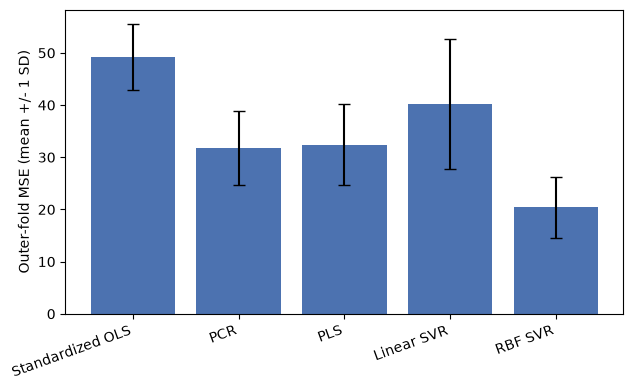

In [6]:
print("mean outer-fold performance (5 outer folds, nested cross-validation):")
display(summary.round(3))
for name, row in summary.iterrows():
    print(f"{name:20s} mean MSE = {row['mean_mse']:.1f}   mean R2 = {row['mean_r2']:+.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(summary.index, summary["mean_mse"], yerr=summary["sd_mse"], capsize=4, color="#4c72b0")
ax.set_ylabel("Outer-fold MSE (mean +/- 1 SD)")
ax.set_xticks(range(len(summary.index)))
ax.set_xticklabels(summary.index, rotation=20, ha="right")
plt.tight_layout()
plt.show()

```{dropdown} Selected hyperparameters per outer fold
The exact hyperparameter(s) inner cross-validation selected for each tuned
model, per outer fold, are available by setting `RUN_FULL_NESTED_CV = True`
above and rerunning the notebook (`fold_results[["model", "outer_fold",
"selected_params"]]`) -- kept out of the main page to keep this section
readable, but never hidden from the runnable code. On this cohort and
split, the selection was stable across every outer fold: PCR consistently
chose 50 components, PLS consistently chose 5 components, linear SVR chose
`C=0.1, epsilon=2` (from the corrected `C` grid `[0.01, 0.1, 1]`, with the
nonconvergent `C=10` removed), and RBF SVR chose `C=100, gamma="scale"`
with `epsilon` fixed at 1 year throughout.
```

On this cohort and split, RBF SVR reaches the lowest outer-fold error
(mean MSE=20.4, R-squared=+0.77) and clearly separates from every other
model across all 5 outer folds. PCR (mean MSE=31.7, R-squared=+0.64) and
PLS (mean MSE=32.4, R-squared=+0.63) perform almost identically here -- a
concrete instance of the earlier guiding question about overlapping
fold-to-fold results: neither method meaningfully beats the other on this
task, even though they construct their components differently. Linear SVR
(mean MSE=40.3, R-squared=+0.55) does better than plain standardized OLS
(mean MSE=49.1, R-squared=+0.43) but worse than either dimensionality-
reduction method, and OLS on the full 360 correlated features remains the
weakest model, consistent with Exercise 8's own supervised-pipeline result.

This is reported as the observed result for this cohort and split, not a
general ranking -- a different dataset or a different feature set could
change which model wins, and RBF's advantage here does not establish that
kernel methods always outperform linear ones.

## 9. Strengths, Weaknesses, and Appropriate Uses

| Method | Useful when | Main limitation |
|---|---|---|
| PCR | Features are numerous and correlated | Components ignore the target |
| PLS | Predictive information may not follow the highest-variance directions | Target-aware components can overfit |
| Linear SVM/SVR | Many features and an approximately linear relationship | Scaling and parameter selection matter |
| Kernel SVM/SVR | A nonlinear relationship is plausible and the sample is not enormous | Less interpretable and increasingly expensive as the sample grows |

Model choice also depends on interpretability, sample size, computational
cost, and the scientific question being asked -- not on validation score
alone.

## 10. Test-Oriented Thinking Questions

1. Why must PCA and PLS be fitted inside each validation fold?
2. When might PLS outperform PCR?
3. Why can PCR discard a direction useful for prediction?
4. What generally happens when `C` increases?
5. How can a very large RBF `gamma` lead to overfitting?
6. Why does an RBF kernel not guarantee better validation performance?
7. What makes a training observation a support vector?
8. Why must all compared models use the same outer folds?
9. If two models have similar scores, what other considerations guide the
   choice?
10. Why is selecting and evaluating a model on the same validation results
    optimistic?

### Check your reasoning for the central concepts

```{dropdown} 1. Why must PCA and PLS be fitted inside each validation fold?
Fitting either one on the full dataset before splitting lets information
from validation rows leak into preprocessing -- the components would be
built partly from data the model is later "tested" on, making the
validation estimate optimistic even though neither method directly uses the
target during prediction.
```

```{dropdown} 4. What generally happens when C increases?
The model is pushed to fit training observations more closely, tolerating
fewer margin violations or regression errors -- training error typically
falls, but an excessively large `C` can overfit noise in the training data
and hurt validation performance.
```

```{dropdown} 6. Why does an RBF kernel not guarantee better validation performance?
A more flexible boundary can fit the training data's actual structure
better, or it can fit noise specific to that training sample. Whether RBF
helps depends on whether the true relationship is nonlinear and whether
enough data supports the extra flexibility -- neither is guaranteed just
because the kernel is available.
```

```{dropdown} 7. What makes a training observation a support vector?
A training observation is a support vector if it lies on or inside the
margin (or, for a soft margin, is misclassified or violates the margin) --
these are the only points whose position actually constrains where the
boundary sits.
```

```{dropdown} 10. Why is selecting and evaluating a model on the same validation results optimistic?
Choosing whichever candidate looks best on a set of scores capitalizes on
that set's own particular noise, so the chosen model's reported score
reflects a small amount of favorable luck on that split, not only genuine
generalization -- the same reasoning nested cross-validation's outer loop
exists to correct for.
```

## 11. Main Takeaways

- PCR uses PCA components without allowing the target to influence them.
- PLS constructs components using the predictor-target relationship.
- SVMs base their solution on support vectors and regularized margins.
- Kernels let SVMs represent nonlinear relationships.
- Greater flexibility can help, but it can also overfit.
- Fair model comparison requires the same nested validation procedure for
  every model compared.